In [1]:
#| echo: false

# This cell will not be rendered but is to hide warnings

import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger('statsforecast').setLevel(logging.ERROR)

import pandas as pd
pd.set_option('display.max_rows', 6)

# Conformal Seasonal Pool (CSP)

> Step-by-step guide on using the `ConformalSeasonalPool` model with `Statsforecast`.

The Conformal Seasonal Pool (CSP) is a **training-free probabilistic forecaster** introduced in
[Manokhin (2026), *Training-Free Probabilistic Time-Series Forecasting with Conformal Seasonal Pools*](https://arxiv.org/abs/2605.03789).
It produces a seasonal naive point forecast together with **well-calibrated prediction intervals**, without estimating a single parameter: the predictive distribution is built entirely from empirical draws of the training history.

In the paper's benchmark, CSP matches or beats deep probabilistic baselines such as DeepNPTS on CRPS while keeping empirical coverage close to the nominal level — and runs **orders of magnitude faster** (seconds instead of hours), since there is nothing to train.

In this notebook we walk through the model on the [UCI ElectricityLoadDiagrams20112014 dataset](https://archive.ics.uci.edu/dataset/321/electricityloaddiagrams20112014) — the raw source of the electricity benchmark used in the paper — and reproduce the paper's rolling-origin evaluation protocol to confirm that the intervals are calibrated.

## How the model works

The point forecast is exactly a [Seasonal Naive](../../src/core/models.html#seasonalnaive) forecast $\mu_h$: the value observed one seasonal period ago. All of the model's machinery goes into the **predictive distribution around** $\mu_h$, which is estimated from `n_samples` draws of a two-component mixture:

1. **Seasonal pool.** Historical observations at the *same seasonal phase* as the forecast target (e.g., all past 3 PM values when forecasting 3 PM), sampled with exponential recency weights $\propto e^{-\lambda \cdot \text{age}}$ so that newer observations are drawn more often (`decay` = $\lambda$).
2. **Calibration residuals.** Signed seasonal-naive errors $r_t = y_t - y_{t-m}$ computed on the most recent `calib_frac` fraction of the history, added back to the point forecast: $\mu_h + r$.

Each sample comes from the seasonal pool with probability $w$ and from the residual component with probability $1-w$. The `variant` parameter controls $w$:

- `"fixed"` (**CSP-Fixed**): $w = 0.5$ always.
- `"adaptive"` (**CSP-Adaptive**): $w = 0$ when there is no seasonality (`season_length` ≤ 1), $w = 0.3$ when the seasonal pool is thin (fewer than 3 same-phase observations), and $w = 0.5$ otherwise.

Prediction intervals are empirical quantiles of the samples with a **finite-sample conformal correction**: the lower cut uses $\lfloor(n+1)q\rfloor/n$ and the upper cut $\lceil(n+1)q\rceil/n$, which orients the quantile estimates conservatively so that nominal coverage is respected even with a modest sample budget.

**Hyperparameters**

| Parameter | Default | Meaning |
|---|---|---|
| `season_length` | — | Observations per seasonal cycle (24 for hourly data with a daily cycle). |
| `n_samples` | 100 | Mixture samples used to estimate the intervals. A level-$L$ interval needs at least $\lceil 2/(1-L/100)\rceil - 1$ samples (≥ 40 for 95%). |
| `variant` | `"adaptive"` | `"adaptive"` or `"fixed"` mixture weight (see above). |
| `calib_frac` | 0.5 | Fraction of the most recent history used for the calibration residual pool. |
| `decay` | 0.01 | Exponential recency rate for the seasonal pool weights. |

**When to use CSP.** Strongly seasonal series where you need calibrated prediction intervals at essentially zero computational cost — for example as a probabilistic baseline before reaching for heavier models, or in large-scale settings where per-series training is too expensive.

## Loading libraries and data

:::{.callout-tip}
Statsforecast will be needed. To install, see [instructions](../getting-started/installation.html).
:::

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from statsforecast import StatsForecast
from statsforecast.models import ConformalSeasonalPool, SeasonalNaive

### Download the electricity dataset

We use the [ElectricityLoadDiagrams20112014](https://archive.ics.uci.edu/dataset/321/electricityloaddiagrams20112014) dataset from the UCI Machine Learning Repository: electricity consumption (kW) of 370 Portuguese clients, recorded every 15 minutes from 2011 to 2014. This is the raw source behind the hourly `electricity` benchmark on which the CSP paper is evaluated.

:::{.callout-warning}
The zip file is about 250 MB. The cell below caches it locally, so it is only downloaded once.
:::

In [3]:
import zipfile
from pathlib import Path
from urllib.request import urlretrieve

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
DATA_URL = "https://archive.ics.uci.edu/static/public/321/electricityloaddiagrams20112014.zip"
zip_path = DATA_DIR / "electricityloaddiagrams20112014.zip"
txt_path = DATA_DIR / "LD2011_2014.txt"

if not txt_path.exists():
    if not zip_path.exists():
        urlretrieve(DATA_URL, zip_path)
    with zipfile.ZipFile(zip_path) as f:
        f.extract("LD2011_2014.txt", DATA_DIR)

The file is semicolon-separated with decimal commas. Each timestamp marks the end of a 15-minute interval, so we aggregate to hourly totals (the convention used by the GluonTS `electricity` benchmark). To keep the notebook fast we work with ten clients over the last three months of 2014, keeping only clients that are active (non-zero) throughout the window — some clients joined after 2011 and their earlier readings are recorded as zero.

In [4]:
raw = pd.read_csv(txt_path, sep=";", decimal=",", index_col=0, parse_dates=True)
hourly = raw.resample("h").sum()

window = hourly.loc["2014-10-01":"2014-12-31"]
active_clients = window.columns[(window > 0).all()]
clients = list(active_clients[:10])

df = (
    window[clients]
    .reset_index(names="ds")
    .melt(id_vars="ds", var_name="unique_id", value_name="y")
)
df

,ds,unique_id,y
0,2014-10-01 00:00:00,MT_002,92.460882
1,2014-10-01 01:00:00,MT_002,79.658606
2,2014-10-01 02:00:00,MT_002,77.524893
...,...,...,...
22077,2014-12-31 21:00:00,MT_012,727.659574
22078,2014-12-31 22:00:00,MT_012,691.489362
22079,2014-12-31 23:00:00,MT_012,665.957447


### Explore the data

The hourly load shows the strong daily seasonality that CSP exploits (`season_length=24`).

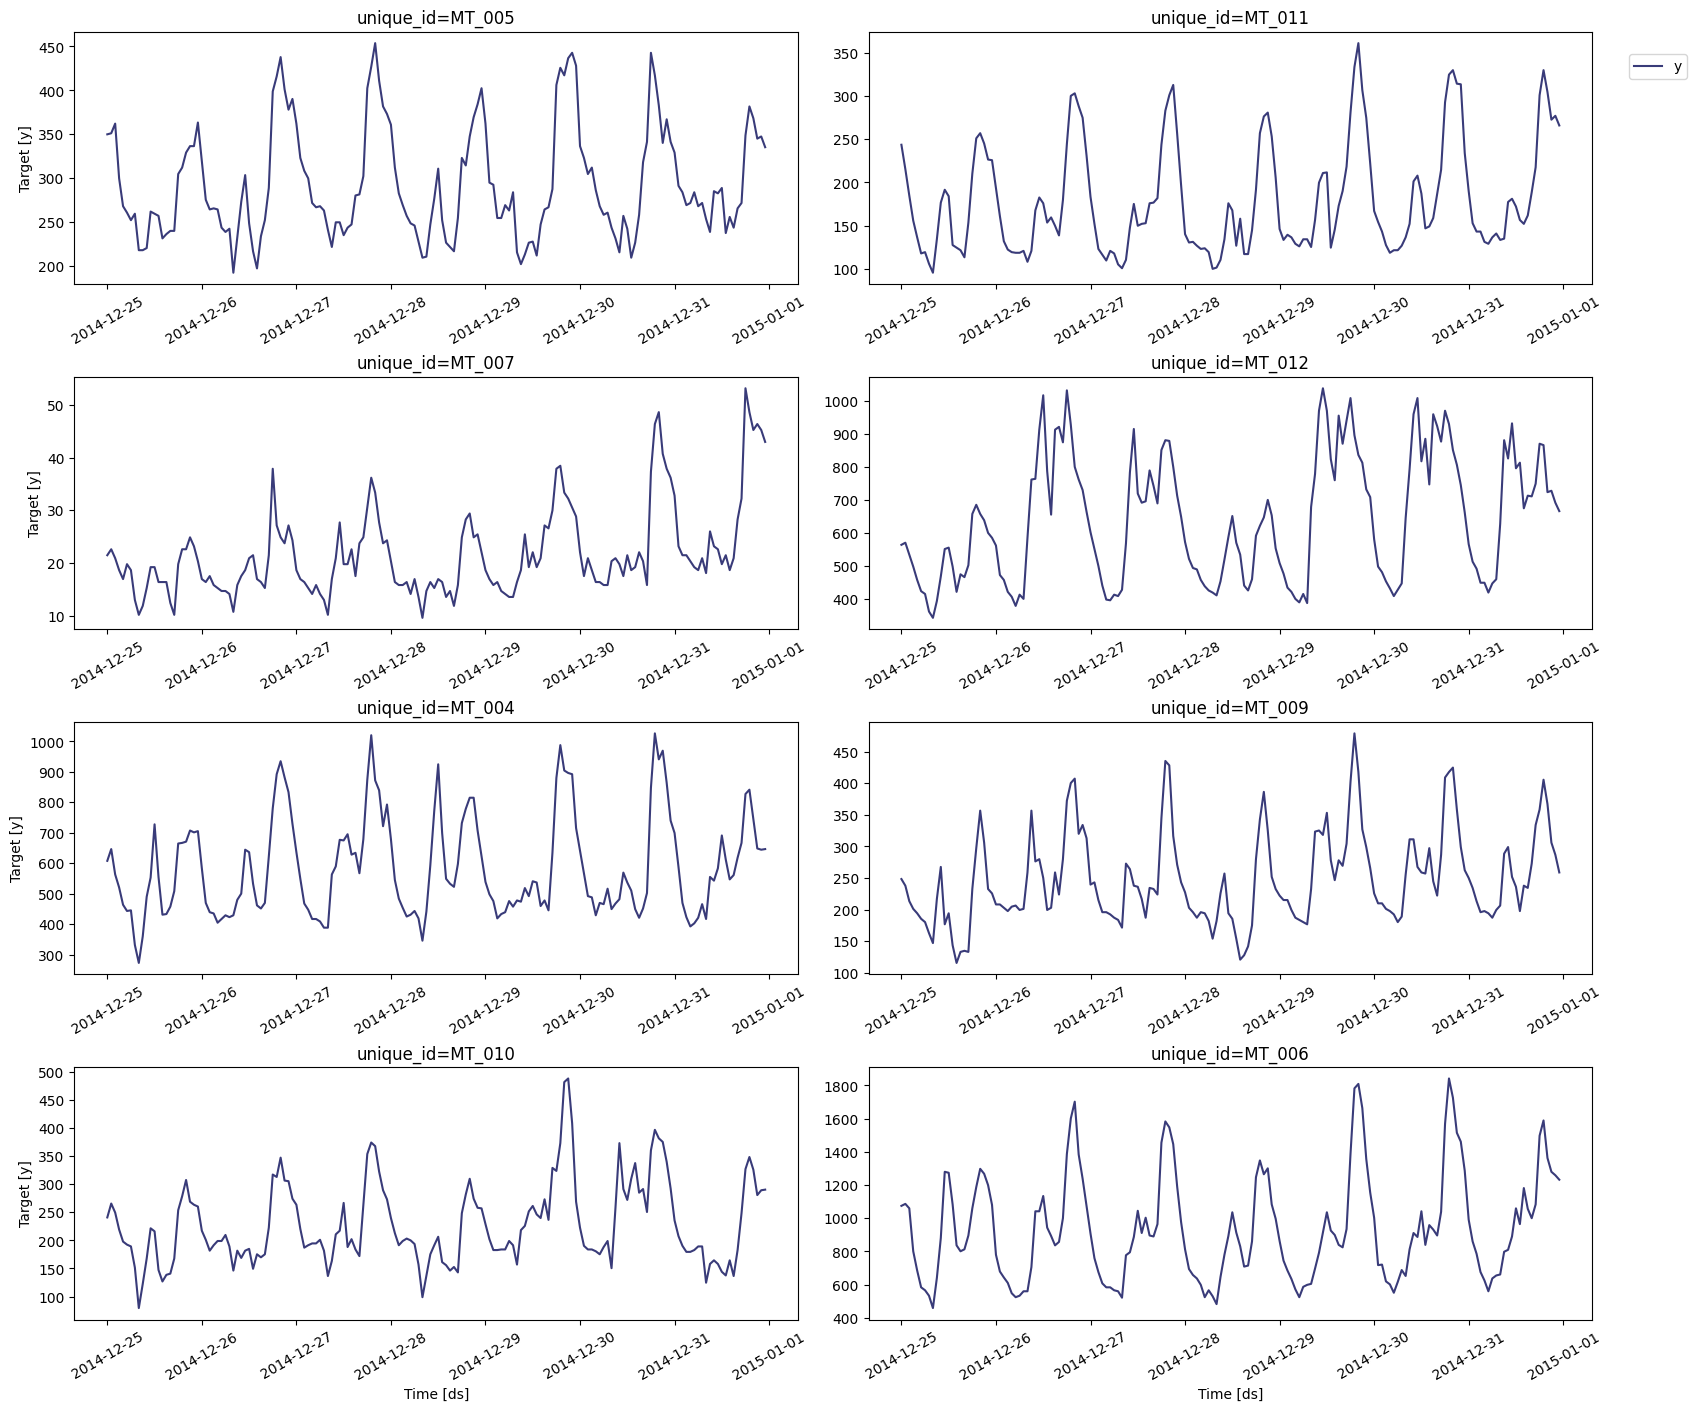

In [5]:
StatsForecast.plot(df, max_insample_length=24 * 7)

## Forecasting with prediction intervals

We instantiate `ConformalSeasonalPool` alongside `SeasonalNaive` and forecast the next day (`h=24`) with 80% and 95% prediction intervals. The default `n_samples=100` comfortably exceeds the minimum of 40 samples required for a non-degenerate 95% interval. Note that CSP requires no training, so `forecast` returns almost instantly.

In [6]:
season_length = 24  # daily seasonality for hourly data
horizon = 24        # forecast one day ahead, as in the paper

sf = StatsForecast(
    models=[
        ConformalSeasonalPool(season_length=season_length),
        SeasonalNaive(season_length=season_length),
    ],
    freq="h",
)

fcst = sf.forecast(df=df, h=horizon, level=[80, 95])
fcst

,unique_id,ds,CSP-Adaptive,CSP-Adaptive-lo-95,CSP-Adaptive-lo-80,CSP-Adaptive-hi-80,CSP-Adaptive-hi-95,SeasonalNaive,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-80,SeasonalNaive-hi-95
0,MT_002,2015-01-01 00:00:00,78.947368,62.588905,75.391181,82.503556,93.250356,78.947368,69.046924,63.805945,88.847813,94.088792
1,MT_002,2015-01-01 01:00:00,73.257468,63.911807,69.701280,79.658606,84.736842,73.257468,63.357024,58.116045,83.157912,88.398891
2,MT_002,2015-01-01 02:00:00,68.990043,55.277383,64.722617,71.187767,76.842105,68.990043,59.089598,53.848620,78.890487,84.131466
...,...,...,...,...,...,...,...,...,...,...,...,...
237,MT_012,2015-01-01 21:00:00,727.659574,610.468085,631.489362,813.531915,1046.191489,727.659574,589.712550,516.687806,865.606599,938.631343
238,MT_012,2015-01-01 22:00:00,691.489362,599.914894,634.042553,744.680851,853.276596,691.489362,553.542337,480.517594,829.436386,902.461130
239,MT_012,2015-01-01 23:00:00,665.957447,529.404255,553.191489,823.000000,957.702128,665.957447,528.010422,454.985679,803.904471,876.929215


The point forecast of CSP is *exactly* the seasonal naive forecast — the value the model adds is the calibrated intervals around it:

In [7]:
np.allclose(fcst["CSP-Adaptive"], fcst["SeasonalNaive"])

True

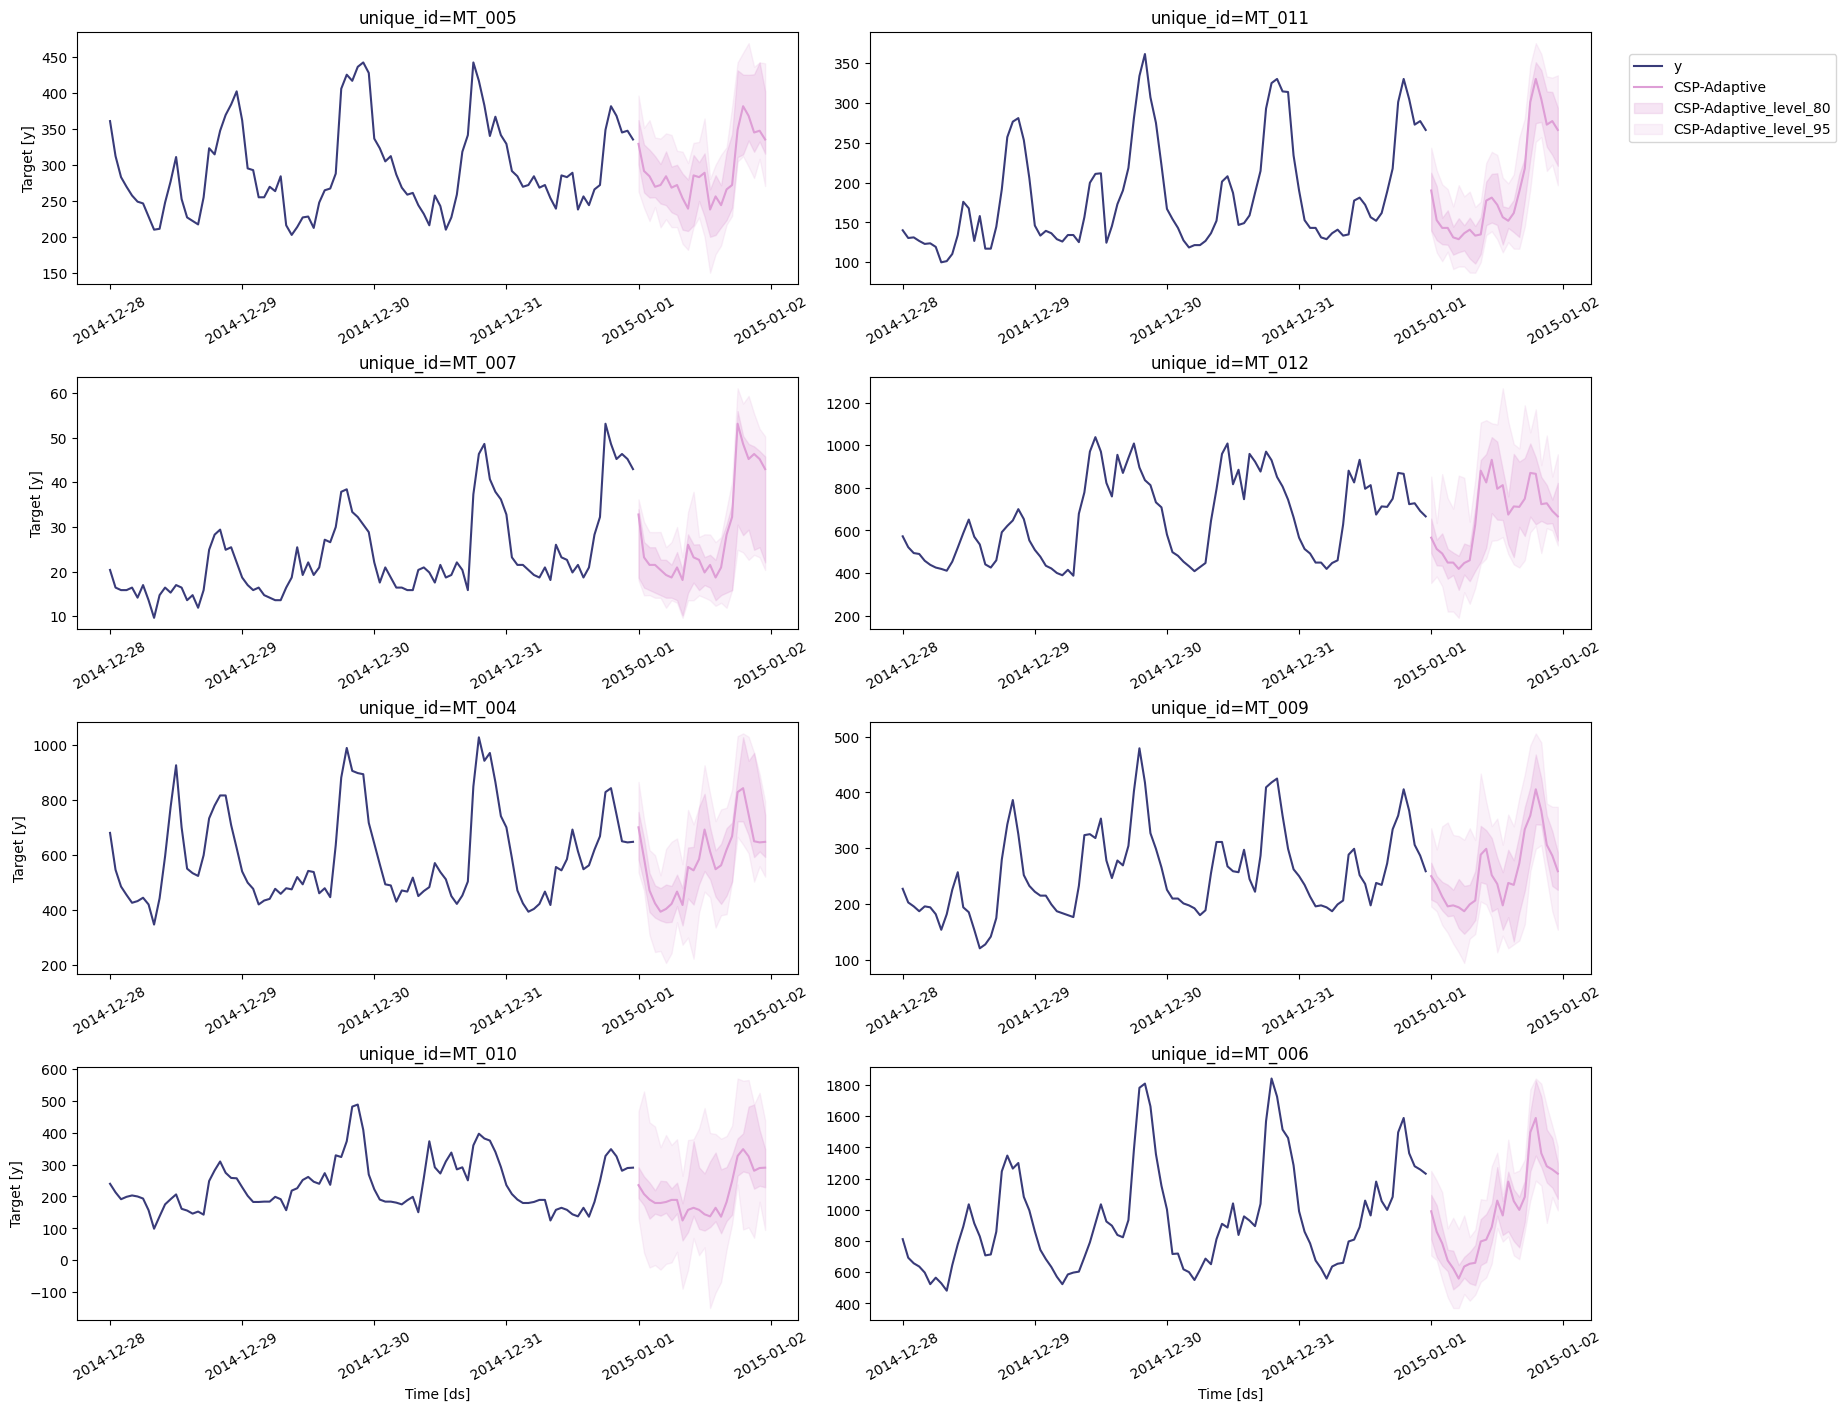

In [8]:
sf.plot(df, fcst, level=[80, 95], max_insample_length=24 * 4, models=["CSP-Adaptive"])

## Evaluating calibration with the paper's protocol

The paper evaluates each method with a **rolling-origin protocol**: 7 non-overlapping evaluation windows per series, each one day long (`h=24`, stride 24). `StatsForecast.cross_validation` implements exactly this. We request the levels `[20, 40, 60, 80]`, whose interval bounds correspond to the quantile grid $q \in \{0.1, 0.2, \ldots, 0.9\}$ used by the paper's CRPS and quantile-loss metrics, plus level 95 for the coverage check.

In [9]:
%%time
cv_df = sf.cross_validation(
    df=df,
    h=horizon,
    n_windows=7,
    step_size=horizon,
    level=[20, 40, 60, 80, 95],
)
cv_df

CPU times: user 58.9 ms, sys: 739 μs, total: 59.6 ms
Wall time: 59.5 ms


,unique_id,ds,cutoff,y,CSP-Adaptive,CSP-Adaptive-lo-95,CSP-Adaptive-lo-80,CSP-Adaptive-lo-60,CSP-Adaptive-lo-40,CSP-Adaptive-lo-20,...,SeasonalNaive-lo-20,SeasonalNaive-lo-40,SeasonalNaive-lo-60,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-20,SeasonalNaive-hi-40,SeasonalNaive-hi-60,SeasonalNaive-hi-80,SeasonalNaive-hi-95
0,MT_002,2014-12-25 00:00:00,2014-12-24 23:00:00,79.658606,81.792319,71.820768,74.679943,76.102418,76.102418,76.813656,...,79.832977,77.736697,75.283368,71.881024,66.634301,83.751661,85.847940,88.301269,91.703613,96.950336
1,MT_002,2014-12-25 01:00:00,2014-12-24 23:00:00,81.081081,72.546230,63.911807,68.278805,69.701280,69.701280,71.123755,...,70.586888,68.490609,66.037280,62.634936,57.388213,74.505572,76.601852,79.055181,82.457525,87.704248
2,MT_002,2014-12-25 02:00:00,2014-12-24 23:00:00,76.102418,68.278805,55.462304,64.011380,66.856330,66.856330,66.856330,...,66.319463,64.223184,61.769854,58.367510,53.120788,70.238147,72.334427,74.787756,78.190100,83.436822
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,MT_012,2014-12-31 21:00:00,2014-12-30 23:00:00,727.659574,806.382979,546.808511,638.297872,700.000000,744.255319,762.978723,...,779.073326,749.855015,715.660080,668.237614,595.107875,833.692631,862.910942,897.105877,944.528344,1017.658083
1678,MT_012,2014-12-31 22:00:00,2014-12-30 23:00:00,691.489362,744.680851,480.765957,618.936170,653.191489,692.553191,712.765957,...,717.371198,688.152887,653.957953,606.535486,533.405747,771.990504,801.208815,835.403750,882.826216,955.955955
1679,MT_012,2014-12-31 23:00:00,2014-12-30 23:00:00,665.957447,661.702128,539.872340,567.872340,595.319149,629.148936,648.936170,...,634.392475,605.174164,570.979229,523.556763,450.427024,689.011780,718.230091,752.425026,799.847493,872.977232


Note the wall-clock time above: the full 7-window evaluation of both models over ten series runs in well under a second on CPU — the training-free speed the paper reports (its deep baseline needs hours for the same protocol).

We now compute the paper's metrics with [utilsforecast](https://nixtlaverse.nixtla.io/utilsforecast):

- **Scaled CRPS** and **mean quantile loss** over $q \in \{0.1, \ldots, 0.9\}$ — the headline distributional accuracy metrics;
- **Empirical 95% coverage** — the fraction of observations inside the 95% interval, which should be close to 0.95 for a calibrated model;
- **Mean 95% interval width** — the sharpness of the intervals.

In [10]:
import utilsforecast.losses as ufl
from utilsforecast.evaluation import evaluate

accuracy = evaluate(
    cv_df,
    metrics=[ufl.scaled_crps, ufl.mqloss],
    level=[20, 40, 60, 80],
    agg_fn="mean",
)
accuracy.groupby("metric")[["CSP-Adaptive", "SeasonalNaive"]].mean()

,CSP-Adaptive,SeasonalNaive
metric,,
mqloss,22.820591,28.767123
scaled_crps,0.100693,0.125018


In [11]:
coverage = evaluate(cv_df, metrics=[ufl.coverage], level=[95], agg_fn="mean")
summary = coverage.groupby("metric")[["CSP-Adaptive", "SeasonalNaive"]].mean()
summary.loc["mean 95% interval width"] = [
    (cv_df[f"{m}-hi-95"] - cv_df[f"{m}-lo-95"]).mean()
    for m in ["CSP-Adaptive", "SeasonalNaive"]
]
summary

,CSP-Adaptive,SeasonalNaive
metric,,
coverage_level95,0.939286,0.838690
mean 95% interval width,306.329187,257.117391


The results mirror the paper's findings:

- **CSP's empirical 95% coverage is close to the nominal level** (the paper reports a mean of 0.89 across its six datasets), while the parametric Gaussian intervals of `SeasonalNaive` undercover noticeably.

All of this comes from a model with **zero trained parameters** that evaluates in a fraction of a second.

## Fixed vs. adaptive variant

With `variant="fixed"` the mixture weight is always $w=0.5$; the adaptive variant only deviates from this when seasonality is absent (`season_length` ≤ 1) or the seasonal pool is thin. On a series this long the two variants behave identically, so to see the adaptive rule act we forecast from a **short history** — two and a half days, so each hour of the day has been observed at most 3 times and the adaptive rule shrinks the seasonal pool's weight to 0.3, leaning more on the calibration residuals:

In [12]:
short_series = df.query("unique_id == 'MT_002'").tail(60)  # 2.5 days of history

sf_variants = StatsForecast(
    models=[
        ConformalSeasonalPool(season_length=season_length, variant="adaptive"),
        ConformalSeasonalPool(season_length=season_length, variant="fixed"),
    ],
    freq="h",
)
fcst_short = sf_variants.forecast(df=short_series, h=horizon, level=[95])

pd.DataFrame({
    "mean 95% width": [
        (fcst_short[f"{m}-hi-95"] - fcst_short[f"{m}-lo-95"]).mean()
        for m in ["CSP-Adaptive", "CSP-Fixed"]
    ]
}, index=["CSP-Adaptive", "CSP-Fixed"])

,mean 95% width
CSP-Adaptive,31.175616
CSP-Fixed,30.991287


On this well-behaved series the resulting widths are similar — the two sampling pools happen to agree. The adaptive safeguard matters when they don't: with only a couple of same-season observations, a single outlier in the seasonal pool can distort the intervals, and down-weighting the pool keeps them stable. If in doubt, keep the default `variant="adaptive"`; it reduces to the fixed rule whenever the history is rich enough.

## References

- [Valery Manokhin (2026). "Training-Free Probabilistic Time-Series Forecasting with Conformal Seasonal Pools".](https://arxiv.org/abs/2605.03789)
- [`ConformalSeasonalPool` API reference.](../../src/core/models.html#conformalseasonalpool)
- [`SeasonalNaive` API reference.](../../src/core/models.html#seasonalnaive)
- [Conformal prediction intervals for any StatsForecast model.](../tutorials/conformalprediction.html) CSP is *natively* conformal — for models that are not, the `ConformalIntervals` wrapper described in that tutorial adds conformal intervals on top.
- [Trindade, Artur (2015). "ElectricityLoadDiagrams20112014". UCI Machine Learning Repository.](https://archive.ics.uci.edu/dataset/321/electricityloaddiagrams20112014)